In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models import shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights
from torchvision import datasets, transforms, models


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

print("PyTorch versiyon :", torch.__version__)
print("CUDA durumu      :", "Var (GPU kullanılabilir)" if torch.cuda.is_available() else "Yok (CPU)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz :", device)


PyTorch versiyon : 2.4.1+cu121
CUDA durumu      : Var (GPU kullanılabilir)
Kullanılan cihaz : cuda


In [13]:
DATASET_PATH = "./tr_signLanguage_dataset"   
IMG_SIZE = 128
BATCH_SIZE = 64  

print("Dataset klasörü var mı?:", os.path.exists(DATASET_PATH))
print("İçindekiler:", os.listdir(DATASET_PATH))


Dataset klasörü var mı?: True
İçindekiler: ['test', 'train']


In [14]:
train_dir = os.path.join(DATASET_PATH, "train")
test_dir  = os.path.join(DATASET_PATH, "test")

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)


train_size = int(len(train_dataset)*0.8)
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])


train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes

print(f"\nTrain set: {len(train_data)}")
print(f"Val set  : {len(val_data)}")
print(f"Test set : {len(test_dataset)}")
print("\nSınıf Sayısı:", len(class_names))
print("Sınıflar:", class_names)



Train set: 95520
Val set  : 23880
Test set : 47786

Sınıf Sayısı: 26
Sınıflar: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']


In [15]:
def build_mobilenetv2():
    weights = MobileNet_V2_Weights.DEFAULT
    model = mobilenet_v2(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, len(class_names))

    return model.to(device)

mobilenet = build_mobilenetv2()
print("MobileNetV2 başarıyla oluşturuldu.")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Berkay/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 8.66MB/s]


MobileNetV2 başarıyla oluşturuldu.


In [17]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct = 0.0, 0

    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / len(dataloader.dataset) * 100
    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / len(dataloader.dataset) * 100
    return epoch_loss, epoch_acc


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.parameters(), lr=0.001)

history_mobile_test = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\n MobileNetV2 sanity-check eğitim başlıyor...\n")

for epoch in range(1, 4):
    train_loss, train_acc = train_one_epoch(mobilenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate_one_epoch(mobilenet, val_loader, criterion, device)

    history_mobile_test["train_loss"].append(train_loss)
    history_mobile_test["val_loss"].append(val_loss)
    history_mobile_test["train_acc"].append(train_acc)
    history_mobile_test["val_acc"].append(val_acc)

    print(f"Epoch [{epoch}/3] -> Train Acc:{train_acc:.2f}% | Val Acc:{val_acc:.2f}%")

print("\n Kısa test eğitimi tamamlandı.\n")



 MobileNetV2 sanity-check eğitim başlıyor...

Epoch [1/3] -> Train Acc:95.31% | Val Acc:98.81%
Epoch [2/3] -> Train Acc:98.41% | Val Acc:98.54%
Epoch [3/3] -> Train Acc:98.60% | Val Acc:99.38%

 Kısa test eğitimi tamamlandı.



In [21]:
mobile_configs = [
    {"lr":0.001,   "batch":64, "opt":"adam"},
    {"lr":0.0005,  "batch":64, "opt":"adam"},
    {"lr":0.0003,  "batch":128,"opt":"adam"},
    {"lr":0.0005,  "batch":64, "opt":"sgd"},
]

results_mobile = []
criterion = nn.CrossEntropyLoss()

def get_optimizer_mobile(opt_name, model_params, lr):
    if opt_name == "adam":
        return optim.Adam(model_params, lr=lr)
    else:
        return optim.SGD(model_params, lr=lr, momentum=0.9)


print("\n===== MobileNetV2 Tuning Başladı =====\n")

for i, cfg in enumerate(mobile_configs, start=1):
    print(f"\n---- Config {i}/{len(mobile_configs)} ---- ", cfg)

    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, len(class_names))
    mobilenet.to(device)

    optimizer = get_optimizer_mobile(cfg["opt"], mobilenet.parameters(), cfg["lr"])

    best_val = 0
    for epoch in range(1,4): # 3 kısa tuning epoch
        train_loss, train_acc = train_one_epoch(mobilenet, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(mobilenet, val_loader, criterion, device)

        print(f"Epoch {epoch}/3 -> Train Acc:{train_acc:.2f}% | Val Acc:{val_acc:.2f}%")

        if val_acc > best_val:
            best_val = val_acc

    results_mobile.append((cfg, best_val))

print("\n===== Tuning Bitti - Sonuçlar =====\n")
for r in results_mobile:
    print(r)



===== MobileNetV2 Tuning Başladı =====


---- Config 1/4 ----  {'lr': 0.001, 'batch': 64, 'opt': 'adam'}


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Berkay/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 10.1MB/s]


Epoch 1/3 -> Train Acc:93.49% | Val Acc:96.70%
Epoch 2/3 -> Train Acc:97.33% | Val Acc:98.76%
Epoch 3/3 -> Train Acc:97.98% | Val Acc:98.91%

---- Config 2/4 ----  {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 -> Train Acc:95.34% | Val Acc:98.91%
Epoch 2/3 -> Train Acc:98.35% | Val Acc:98.12%
Epoch 3/3 -> Train Acc:98.75% | Val Acc:99.41%

---- Config 3/4 ----  {'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch 1/3 -> Train Acc:95.98% | Val Acc:98.69%
Epoch 2/3 -> Train Acc:98.88% | Val Acc:99.09%
Epoch 3/3 -> Train Acc:99.13% | Val Acc:99.00%

---- Config 4/4 ----  {'lr': 0.0005, 'batch': 64, 'opt': 'sgd'}
Epoch 1/3 -> Train Acc:85.69% | Val Acc:98.22%
Epoch 2/3 -> Train Acc:98.38% | Val Acc:99.28%
Epoch 3/3 -> Train Acc:99.20% | Val Acc:99.50%

===== Tuning Bitti - Sonuçlar =====

({'lr': 0.001, 'batch': 64, 'opt': 'adam'}, 98.91122278056952)
({'lr': 0.0005, 'batch': 64, 'opt': 'adam'}, 99.40536013400335)
({'lr': 0.0003, 'batch': 128, 'opt': 'adam'}, 99.08710217755444)
({'lr': 

In [22]:
print("\n MobileNetV2 Final Eğitim \n")

mobilenet_final = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet_final.classifier[1] = nn.Linear(mobilenet_final.last_channel, len(class_names))
mobilenet_final.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mobilenet_final.parameters(), lr=0.0005, momentum=0.9)

epochs = 10
mobile_history_final = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(1, epochs+1):
    train_loss, train_acc = train_one_epoch(mobilenet_final, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate_one_epoch(mobilenet_final, val_loader, criterion, device)

    mobile_history_final["train_loss"].append(train_loss)
    mobile_history_final["val_loss"].append(val_loss)
    mobile_history_final["train_acc"].append(train_acc)
    mobile_history_final["val_acc"].append(val_acc)

    print(f"Epoch [{epoch}/{epochs}] | Train Acc:{train_acc:.4f} | Val Acc:{val_acc:.4f}")

print("\n MobileNetV2 Final Eğitim Tamamlandı")



 MobileNetV2 Final Eğitim 

Epoch [1/10] | Train Acc:86.3955 | Val Acc:98.4171
Epoch [2/10] | Train Acc:98.3825 | Val Acc:99.3049
Epoch [3/10] | Train Acc:99.1677 | Val Acc:99.4807
Epoch [4/10] | Train Acc:99.4713 | Val Acc:99.6231
Epoch [5/10] | Train Acc:99.5886 | Val Acc:99.6692
Epoch [6/10] | Train Acc:99.6901 | Val Acc:99.7111
Epoch [7/10] | Train Acc:99.7383 | Val Acc:99.7739
Epoch [8/10] | Train Acc:99.7697 | Val Acc:99.7906
Epoch [9/10] | Train Acc:99.7802 | Val Acc:99.7864
Epoch [10/10] | Train Acc:99.8440 | Val Acc:99.7697

 MobileNetV2 Final Eğitim Tamamlandı


In [23]:
print("\n MobileNetV2 Test \n")

mobile_test_acc = 0
y_true_m, y_pred_m = [], []

mobilenet_final.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_final(images)
        _, preds = torch.max(outputs,1)

        y_true_m.extend(labels.cpu().numpy())
        y_pred_m.extend(preds.cpu().numpy())

mobile_test_acc = accuracy_score(y_true_m, y_pred_m)

print(f"\n MobileNetV2 FINAL TEST ACC: {mobile_test_acc*100:.2f}%\n")
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true_m, y_pred_m, target_names=class_names))



 MobileNetV2 Test 


 MobileNetV2 FINAL TEST ACC: 99.88%


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.00      1

In [24]:
torch.save(mobilenet_final.state_dict(), "MobileNetV2_final_model.pth")
print(" MobileNetV2_final_model.pth kaydedildi.")


 MobileNetV2_final_model.pth kaydedildi.


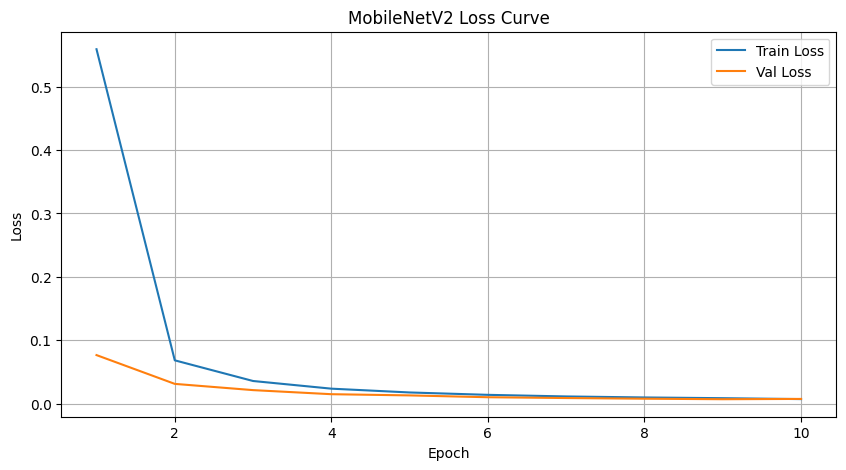

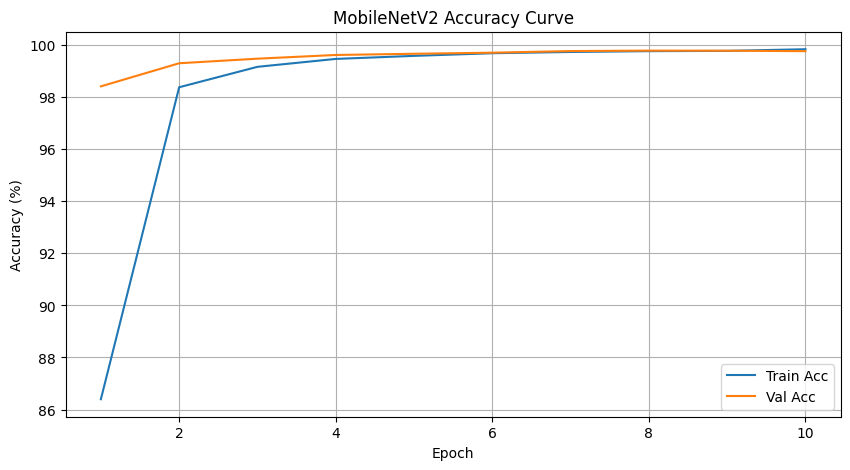

 MobileNetV2_loss_curve.png ve MobileNetV2_accuracy_curve.png kaydedildi.


In [25]:
epochs = range(1, len(mobile_history_final["train_loss"]) + 1)


plt.figure(figsize=(10,5))
plt.plot(epochs, mobile_history_final["train_loss"], label="Train Loss")
plt.plot(epochs, mobile_history_final["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss Curve")
plt.legend()
plt.grid(True)
plt.savefig("MobileNetV2_loss_curve.png", dpi=300)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(epochs, mobile_history_final["train_acc"], label="Train Acc")
plt.plot(epochs, mobile_history_final["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MobileNetV2 Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig("MobileNetV2_accuracy_curve.png", dpi=300)
plt.show()

print(" MobileNetV2_loss_curve.png ve MobileNetV2_accuracy_curve.png kaydedildi.")


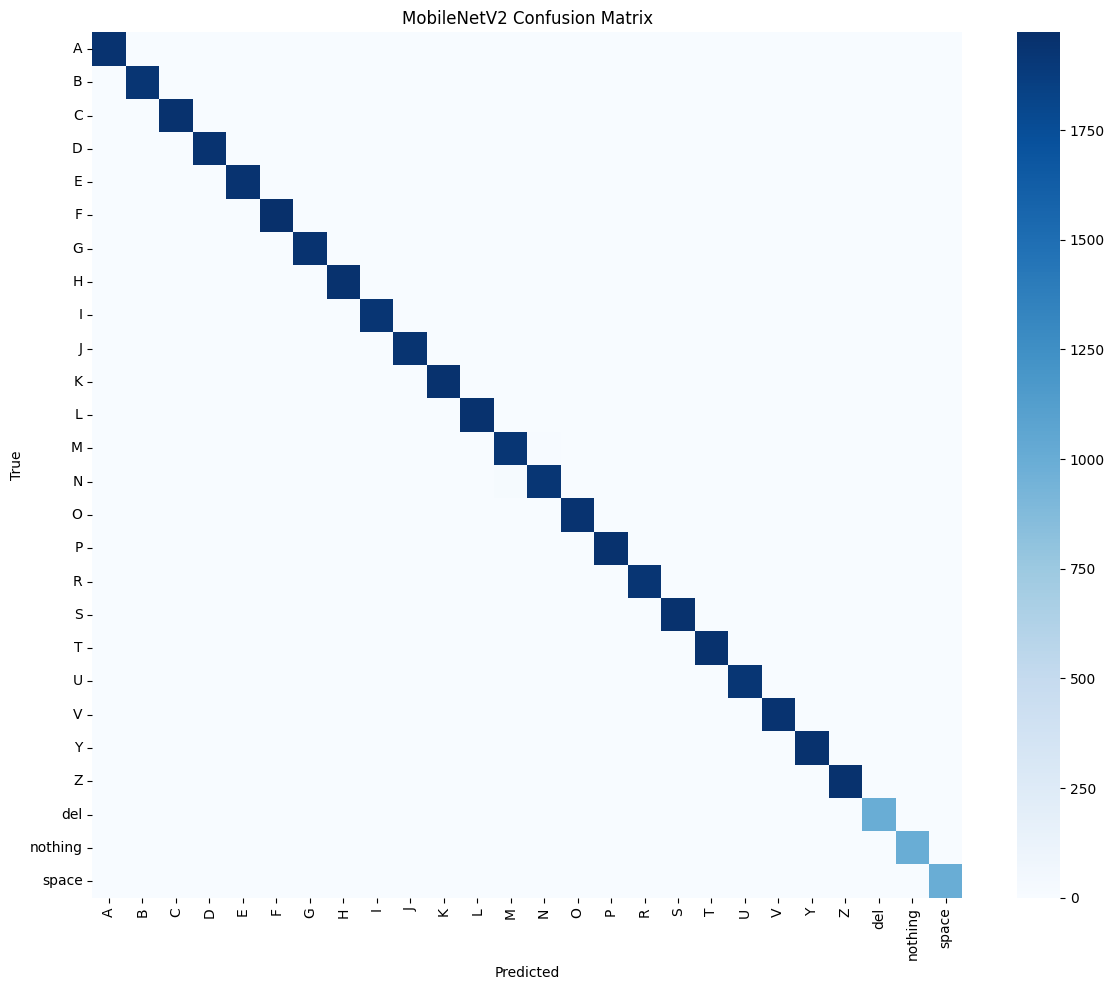

 MobileNetV2_confusion_matrix.png kaydedildi.


In [26]:
cm_mobile = confusion_matrix(y_true_m, y_pred_m)

plt.figure(figsize=(12,10))
sns.heatmap(cm_mobile,
            annot=False,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.savefig("MobileNetV2_confusion_matrix.png", dpi=300)
plt.show()

print(" MobileNetV2_confusion_matrix.png kaydedildi.")


In [27]:
from torchvision.models import shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights

print(" ShuffleNet v2 modeli yükleniyor")

shufflenet = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
shufflenet.fc = nn.Linear(shufflenet.fc.in_features, len(class_names))
shufflenet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(shufflenet.parameters(), lr=0.001)

print(" ShuffleNetV2 hazır.")


 ShuffleNet v2 modeli yükleniyor


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to C:\Users\Berkay/.cache\torch\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 11.8MB/s]

 ShuffleNetV2 hazır.


In [28]:
print("\n ShuffleNetV2 sanity-check eğitim başlıyor\n")

history_shuffle_test = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(1,4):
    train_loss, train_acc = train_one_epoch(shufflenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate_one_epoch(shufflenet, val_loader, criterion, device)

    history_shuffle_test["train_loss"].append(train_loss)
    history_shuffle_test["val_loss"].append(val_loss)
    history_shuffle_test["train_acc"].append(train_acc)
    history_shuffle_test["val_acc"].append(val_acc)

    print(f"Epoch [{epoch}/3] -> Train Acc:{train_acc:.2f}% | Val Acc:{val_acc:.2f}%")

print("\n✔ ShuffleNet sanity-check tamamlandı.")



 ShuffleNetV2 sanity-check eğitim başlıyor

Epoch [1/3] -> Train Acc:93.17% | Val Acc:98.14%
Epoch [2/3] -> Train Acc:98.53% | Val Acc:98.79%
Epoch [3/3] -> Train Acc:98.88% | Val Acc:99.13%

✔ ShuffleNet sanity-check tamamlandı.


In [30]:
shuffle_configs = [
    {"lr":0.001, "batch":64,  "opt":"adam"},
    {"lr":0.0005,"batch":64,  "opt":"adam"},
    {"lr":0.0003,"batch":128, "opt":"adam"},
    {"lr":0.0005,"batch":64,  "opt":"sgd"}
]

results_shuffle = []
history_shuffle_tuning = []

print("\n===== ShuffleNetV2 Tuning Başlıyor =====\n")

for i, cfg in enumerate(shuffle_configs, start=1):
    print(f"\n---- Config {i}/{len(shuffle_configs)} ---- ", cfg)

    shufflenet = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
    shufflenet.fc = nn.Linear(shufflenet.fc.in_features, len(class_names))
    shufflenet.to(device)

    optimizer = optim.Adam(shufflenet.parameters(), lr=cfg["lr"]) \
                if cfg["opt"]=="adam" else optim.SGD(shufflenet.parameters(), lr=cfg["lr"], momentum=0.9)

    hist = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for epoch in range(1,4):
        train_loss, train_acc = train_one_epoch(shufflenet, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(shufflenet, val_loader, criterion, device)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/3 -> Train Acc:{train_acc:.2f}% | Val Acc:{val_acc:.2f}%")

    best_val = max(hist["val_acc"])
    results_shuffle.append((cfg, best_val))
    history_shuffle_tuning.append(hist)

print("\n===== Tuning Tamamlandı - Sonuçlar =====\n")
for r in results_shuffle:
    print(r)



===== ShuffleNetV2 Tuning Başlıyor =====


---- Config 1/4 ----  {'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 -> Train Acc:93.33% | Val Acc:96.95%
Epoch 2/3 -> Train Acc:98.60% | Val Acc:99.23%
Epoch 3/3 -> Train Acc:98.84% | Val Acc:99.38%

---- Config 2/4 ----  {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch 1/3 -> Train Acc:91.91% | Val Acc:99.24%
Epoch 2/3 -> Train Acc:98.97% | Val Acc:99.43%
Epoch 3/3 -> Train Acc:99.19% | Val Acc:99.54%

---- Config 3/4 ----  {'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch 1/3 -> Train Acc:89.83% | Val Acc:99.14%
Epoch 2/3 -> Train Acc:99.02% | Val Acc:99.47%
Epoch 3/3 -> Train Acc:99.36% | Val Acc:99.51%

---- Config 4/4 ----  {'lr': 0.0005, 'batch': 64, 'opt': 'sgd'}
Epoch 1/3 -> Train Acc:7.61% | Val Acc:12.16%
Epoch 2/3 -> Train Acc:19.67% | Val Acc:27.57%
Epoch 3/3 -> Train Acc:33.33% | Val Acc:39.99%

===== Tuning Tamamlandı - Sonuçlar =====

({'lr': 0.001, 'batch': 64, 'opt': 'adam'}, 99.38442211055276)
({'lr': 0.0005, 'batch': 

In [31]:
print("\n ShuffleNetV2 Final Eğitim \n")


shufflenet_final = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
shufflenet_final.fc = nn.Linear(shufflenet_final.fc.in_features, len(class_names))
shufflenet_final.to(device)

optimizer = optim.Adam(shufflenet_final.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

shuffle_history_final = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(1,11):
    train_loss, train_acc = train_one_epoch(shufflenet_final, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate_one_epoch(shufflenet_final, val_loader, criterion, device)

    shuffle_history_final["train_loss"].append(train_loss)
    shuffle_history_final["val_loss"].append(val_loss)
    shuffle_history_final["train_acc"].append(train_acc)
    shuffle_history_final["val_acc"].append(val_acc)

    print(f"Epoch [{epoch}/10] | Train Acc:{train_acc:.2f}% | Val Acc:{val_acc:.2f}%")

print("\n ShuffleNetV2 Final Eğitim Tamamlandı.")



 ShuffleNetV2 Final Eğitim 

Epoch [1/10] | Train Acc:91.84% | Val Acc:99.06%
Epoch [2/10] | Train Acc:98.92% | Val Acc:99.30%
Epoch [3/10] | Train Acc:99.29% | Val Acc:99.54%
Epoch [4/10] | Train Acc:99.32% | Val Acc:99.30%
Epoch [5/10] | Train Acc:99.50% | Val Acc:99.59%
Epoch [6/10] | Train Acc:99.49% | Val Acc:99.49%
Epoch [7/10] | Train Acc:99.55% | Val Acc:99.61%
Epoch [8/10] | Train Acc:99.63% | Val Acc:99.70%
Epoch [9/10] | Train Acc:99.62% | Val Acc:99.68%
Epoch [10/10] | Train Acc:99.68% | Val Acc:99.68%

 ShuffleNetV2 Final Eğitim Tamamlandı.


In [32]:
print("\n ShuffleNetV2 Final Test \n")

y_true_s, y_pred_s = [], []

shufflenet_final.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = shufflenet_final(imgs)
        _, preds = torch.max(outputs,1)

        y_true_s.extend(labels.cpu().numpy())
        y_pred_s.extend(preds.cpu().numpy())

shuffle_test_acc = accuracy_score(y_true_s, y_pred_s)

print(f"\n ShuffleNetV2 FINAL TEST ACC: {shuffle_test_acc*100:.2f}%\n")

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true_s, y_pred_s, target_names=class_names))



 ShuffleNetV2 Final Test 


 ShuffleNetV2 FINAL TEST ACC: 99.81%


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       0.99      1.00      1.00      1958
           M       0.99      0.99      0.99      1934
           N       0.99      0.99      0.99      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.0

In [33]:
torch.save(shufflenet_final.state_dict(), "ShuffleNetV2_final_model.pth")
print(" ShuffleNetV2_final_model.pth kaydedildi.")


 ShuffleNetV2_final_model.pth kaydedildi.


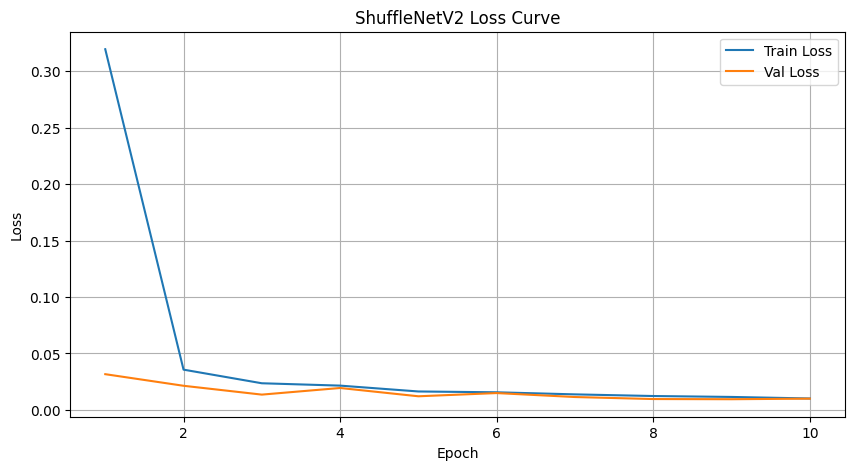

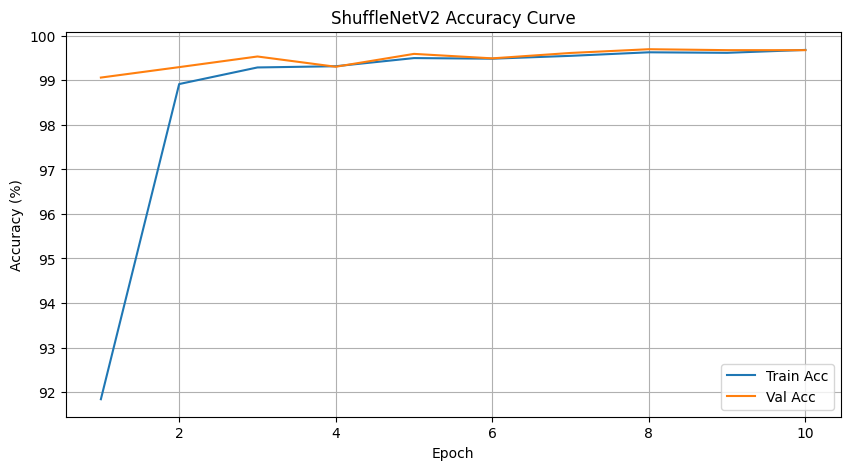

ShuffleNetV2_loss_curve.png ve ShuffleNetV2_accuracy_curve.png kaydedildi.


In [34]:
epochs = range(1, len(shuffle_history_final["train_loss"]) + 1)


plt.figure(figsize=(10,5))
plt.plot(epochs, shuffle_history_final["train_loss"], label="Train Loss")
plt.plot(epochs, shuffle_history_final["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ShuffleNetV2 Loss Curve")
plt.legend()
plt.grid(True)
plt.savefig("ShuffleNetV2_loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, shuffle_history_final["train_acc"], label="Train Acc")
plt.plot(epochs, shuffle_history_final["val_acc"],   label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ShuffleNetV2 Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig("ShuffleNetV2_accuracy_curve.png", dpi=300)
plt.show()

print("ShuffleNetV2_loss_curve.png ve ShuffleNetV2_accuracy_curve.png kaydedildi.")


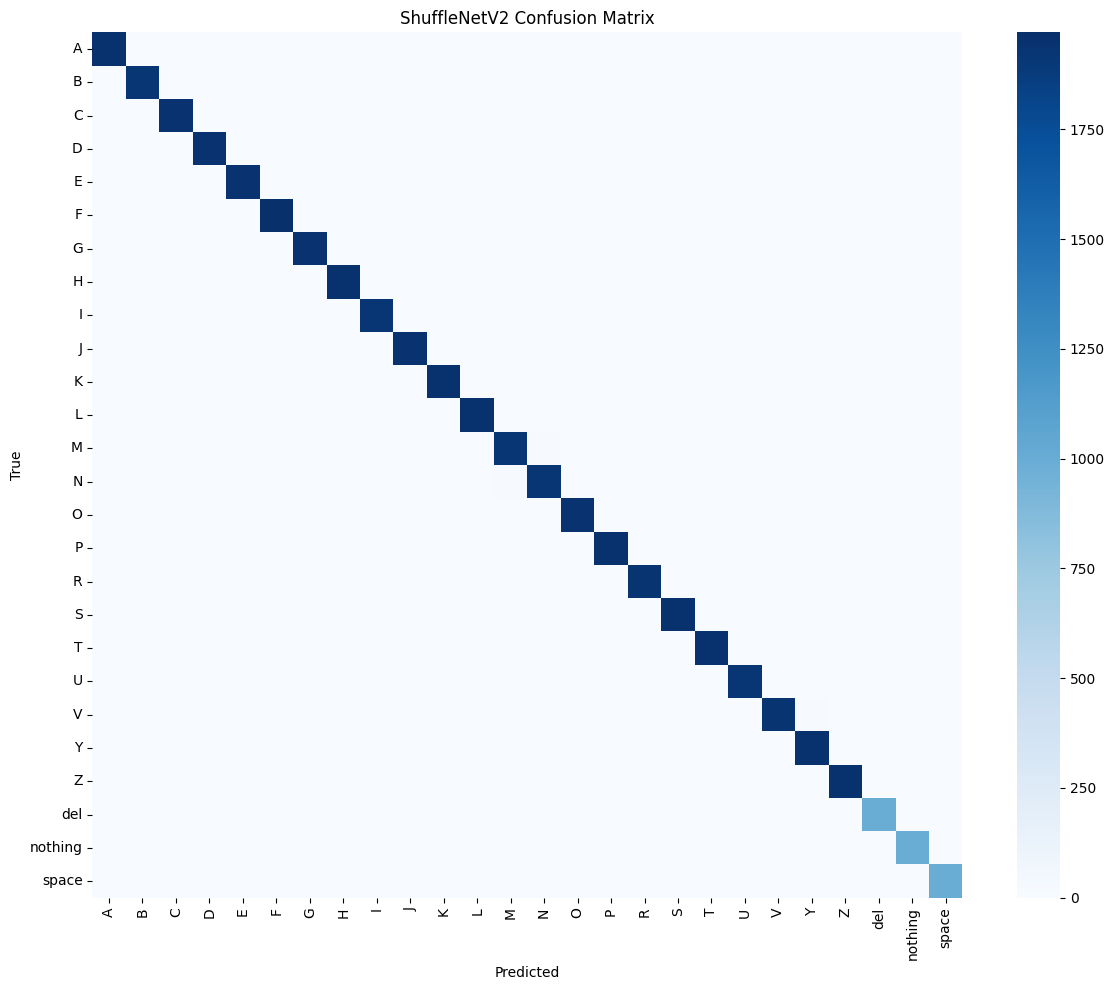

 ShuffleNetV2_confusion_matrix.png kaydedildi.


In [35]:
cm_shuffle = confusion_matrix(y_true_s, y_pred_s)

plt.figure(figsize=(12,10))
sns.heatmap(cm_shuffle,
            annot=False,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ShuffleNetV2 Confusion Matrix")
plt.tight_layout()
plt.savefig("ShuffleNetV2_confusion_matrix.png", dpi=300)
plt.show()

print(" ShuffleNetV2_confusion_matrix.png kaydedildi.")


In [41]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [42]:
print("\n===== MODELLERİN KARŞILAŞTIRILMASI =====\n")   
results_table = {
    "Model":               ["VGG16", "ResNet50", "MobileNetV2", "ShuffleNetV2"],
    "Test Accuracy":   [99.39,   99.55,      99.88,         99.81],
    "Final Val Acc":   [99.18,   99.59,      99.77,         99.68],
    "Macro F1":            [0.99,    1.00,       1.00,          1.00],
    "Learning Rate":       ["0.0003", "0.0005", "0.0005",       "0.0005"],
    "Batch Size":          [128,      64,       64,             64],
    "Optimizer":           ["Adam",   "Adam",   "SGD",          "Adam"],
    "Fine-Tuned":          ["Evet",   "Evet",   "Hayır",        "Hayır"],
    "Epoch":               [12,       10,       10,             10]
}

df_compare = pd.DataFrame(results_table)
print(df_compare)



===== MODELLERİN KARŞILAŞTIRILMASI =====

          Model  Test Accuracy  Final Val Acc  Macro F1 Learning Rate  Batch Size Optimizer Fine-Tuned  Epoch
0         VGG16          99.39          99.18      0.99        0.0003         128      Adam       Evet     12
1      ResNet50          99.55          99.59      1.00        0.0005          64      Adam       Evet     10
2   MobileNetV2          99.88          99.77      1.00        0.0005          64       SGD      Hayır     10
3  ShuffleNetV2          99.81          99.68      1.00        0.0005          64      Adam      Hayır     10


In [50]:
state = torch.load("VGG16_final_model.pth", map_location="cpu")
for k in state.keys():
    print(k)


features.0.weight
features.0.bias
features.2.weight
features.2.bias
features.5.weight
features.5.bias
features.7.weight
features.7.bias
features.10.weight
features.10.bias
features.12.weight
features.12.bias
features.14.weight
features.14.bias
features.17.weight
features.17.bias
features.19.weight
features.19.bias
features.21.weight
features.21.bias
features.24.weight
features.24.bias
features.26.weight
features.26.bias
features.28.weight
features.28.bias
classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.1.weight
classifier.6.1.bias


In [51]:
import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

# ✔ Pretrained değil sıfırdan model çağırıyoruz (çünkü kendi eğitimli ağırlıklarını yükleyeceğiz)
vgg_loaded = vgg16(weights=None)

# 📌 Senin classifier yapına birebir uygun şekilde yeniden kuruyoruz
vgg_loaded.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(4096, len(class_names))  # SON çıkış 26 sınıf
    )
)

# ✔ MODELİ YÜKLE
vgg_loaded.load_state_dict(torch.load("VGG16_final_model.pth", map_location=device), strict=False)

vgg_loaded.to(device)
vgg_loaded.eval()

print("\n✅ Model başarıyla yüklendi ve test için hazır!")



✅ Model başarıyla yüklendi ve test için hazır!


In [52]:
# TEST
y_true_vgg = []
y_pred_vgg = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg_loaded(images)
        _, preds = torch.max(outputs, 1)

        y_true_vgg.extend(labels.cpu().numpy())
        y_pred_vgg.extend(preds.cpu().numpy())

acc = accuracy_score(y_true_vgg, y_pred_vgg)
print(f"\n VGG16 LOAD TEST ACCURACY: {acc*100:.2f}%")
print("\n", classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))



 VGG16 LOAD TEST ACCURACY: 99.39%

               precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      0.99      0.99      1929
           C       1.00      1.00      1.00      1953
           D       1.00      0.97      0.99      1948
           E       0.99      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       0.98      1.00      0.99      1947
           H       1.00      1.00      1.00      1952
           I       0.99      1.00      1.00      1933
           J       1.00      0.99      0.99      1944
           K       0.99      1.00      1.00      1950
           L       0.99      1.00      0.99      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.96      0.98      1941
           O       1.00      0.99      0.99      1945
           P       1.00      1.00      1.00      1953
           R       1.00      0.99      1.00 

In [60]:
state = torch.load("ResNet50_final_model.pth", map_location="cpu")
for k in state.keys():
    print(k)


conv1.weight
bn1.weight
bn1.bias
bn1.running_mean
bn1.running_var
bn1.num_batches_tracked
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.bn1.running_mean
layer1.0.bn1.running_var
layer1.0.bn1.num_batches_tracked
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.bn2.running_mean
layer1.0.bn2.running_var
layer1.0.bn2.num_batches_tracked
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.bn3.running_mean
layer1.0.bn3.running_var
layer1.0.bn3.num_batches_tracked
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.0.downsample.1.running_mean
layer1.0.downsample.1.running_var
layer1.0.downsample.1.num_batches_tracked
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.bn1.running_mean
layer1.1.bn1.running_var
layer1.1.bn1.num_batches_tracked
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.bn2.running_mean
layer1.1.bn2.running_var
layer1.1.bn2.num_batches_tr

In [62]:
import torch
import torch.nn as nn
from torchvision.models import resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_loaded = resnet50(weights=None)
num_features = resnet_loaded.fc.in_features

# 🔥 Eğittiğin modeldeki ile aynı FC yapısı
resnet_loaded.fc = nn.Sequential(
    nn.Dropout(0.5),                  # fc.0
    nn.Linear(num_features, 26)       # fc.1 -> pth içindekiyle aynı!
)

state = torch.load("ResNet50_final_model.pth", map_location=device)
resnet_loaded.load_state_dict(state, strict=False)   # strict=False koyuyoruz çünkü çok küçük fark var
resnet_loaded.to(device)
resnet_loaded.eval()

print("🔥 ResNet50 başarıyla yüklendi!")


🔥 ResNet50 başarıyla yüklendi!


In [63]:
from sklearn.metrics import classification_report, accuracy_score

y_true_res = []
y_pred_res = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_loaded(images)
        _, preds = torch.max(outputs, 1)

        y_true_res.extend(labels.cpu().numpy())
        y_pred_res.extend(preds.cpu().numpy())

acc = accuracy_score(y_true_res, y_pred_res) * 100
print(f"\n🔥 RESNET50 TEST ACCURACY = {acc:.2f}%\n")

print(classification_report(y_true_res, y_pred_res, target_names=class_names))



🔥 RESNET50 TEST ACCURACY = 99.55%

              precision    recall  f1-score   support

           A       0.99      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      0.99      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      0.99      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.97      0.98      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.00      1.00      1953
           R       1.00      1.00      1.00  